<a href="https://colab.research.google.com/github/RayQueen/ucv-svd-image-compression/blob/main/SVDImageCompression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Preparación del entorno


### 0.1.  Sincronización con repositorio de Git Hub

In [ ]:
# Verifica ubicación actual
path = !pwd
path_str = path[0]

# Si el repositorio ya fue clonado intenta actualizar
if path_str == "/content/ucv-svd-image-compression":
    !git pull
# De lo contrario lo clona y corrige la ubicación actual
else:
    !git clone https://github.com/RayQueen/ucv-svd-image-compression.git
    %cd ucv-svd-image-compression/

### 0.2. Librerías necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Implementación computacional

## 1.1. Carga de una imagen de alta resolución y conversión a matriz de intensidades de gris

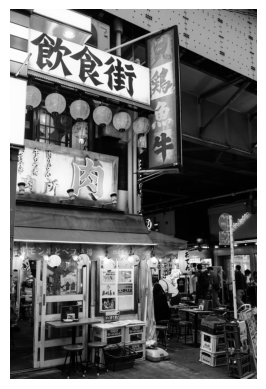

In [62]:
# Abre la imagen a color de alta resolución
originalImg = Image.open('Images/HRImage.jpg')

# Convierte la imagen a escala de grises
grayImg = originalImg.convert('L')

# Guarda la imagen a escala de grises de alta resolución
grayImg.save('Images/grayHRImage.jpg')

# Convierte la imagen a array
grayImgArray = np.asarray(grayImg)

# Muestra la imagen con matplotlib (Temporal)
plt.imshow(grayImgArray, cmap = 'gray')
plt.axis('off')
plt.show()

## 1.2. Cálculo de la SVD de la matriz resultante

Nuestra matriz A será grayImgArray de modo que: A = U * S * Vt,  donde:
- U $\in R^{m×m}$ y Vt $\in R^{n×n}$ son matrices ortogonales
- S es una matriz diagonal con valores singulares $s_1 \geq s_2 \geq ... \geq s_r \geq 0$

In [63]:
# Definimos A para mejor legibilidad
A = grayImgArray

# Calcula las matrices U, S y Vt
U, S, Vt = np.linalg.svd(A)

print("U (Vetores singulares por la izquierda):\n", U)
print("S (Valores singulares):", S)
print("Vt (Vetores singulares por la derecha - Transpuesta):\n", Vt)

U (Vetores singulares por la izquierda):
 [[-0.01841269  0.00923752  0.00165308 ...  0.02150428 -0.00340842
   0.02386737]
 [-0.01845066  0.00916623  0.00148735 ... -0.0200295  -0.00784032
  -0.02350786]
 [-0.01845907  0.00889348  0.00125746 ...  0.02495083  0.03622614
   0.01535002]
 ...
 [-0.0091408   0.01720603 -0.00561168 ...  0.33356056 -0.20574747
   0.05462908]
 [-0.00912282  0.01743915 -0.00566997 ... -0.20729484  0.30824977
  -0.13668723]
 [-0.00910819  0.01755469 -0.00578148 ...  0.06424801 -0.13448047
   0.1363128 ]]
S (Valores singulares): [3.40638451e+05 9.09860915e+04 8.08061737e+04 ... 1.19778263e+01
 1.17050019e+01 1.11042928e+01]
Vt (Vetores singulares por la derecha - Transpuesta):
 [[-0.02255083 -0.02254582 -0.02253208 ... -0.01234599 -0.01234788
  -0.01235297]
 [ 0.01793824  0.01813554  0.01829452 ...  0.01433404  0.01439012
   0.01438601]
 [-0.0107077  -0.0106493  -0.01058423 ... -0.01406754 -0.01451308
  -0.01481517]
 ...
 [ 0.01518557 -0.03244911  0.03781007 ... 

## 1.3. Construcción de aproximaciones $A_k$

### 1.3.1.  k = 5

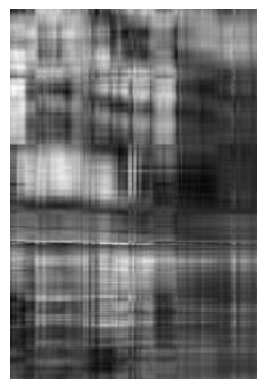

In [64]:
# Reconstruimos la imagen usando solo 5 componentes
k = 5
Ak5 = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])

# Guarda la imagen reconstruida
plt.imsave('Images/grayAk5.jpg', Ak5, cmap='gray')

# Muestra el resultado de la reconstrucción
plt.imshow(Ak5, cmap = 'gray')
plt.axis('off')
plt.show()

### 1.3.2. k = 20

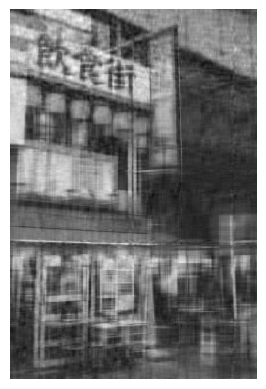

In [65]:
# Reconstruimos la imagen usando 20 componentes
k = 20
Ak20 = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])

# Guarda la imagen reconstruida
plt.imsave('Images/grayAk20.jpg', Ak20, cmap='gray')

# Muestra el resultado de la reconstrucción
plt.imshow(Ak20, cmap = 'gray')
plt.axis('off')
plt.show()

### 1.3.3. k = 50

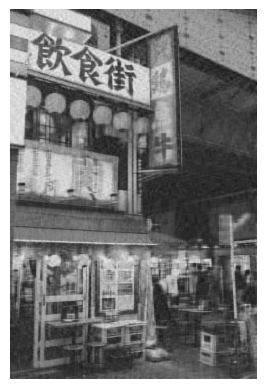

In [66]:
# Reconstruimos la imagen usando 50 componentes
k = 50
Ak50 = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])

# Guarda la imagen reconstruida
plt.imsave('Images/grayAk50.jpg', Ak50, cmap='gray')

# Muestra el resultado de la reconstrucción
plt.imshow(Ak50, cmap = 'gray')
plt.axis('off')
plt.show()

### 1.3.4. k = 100

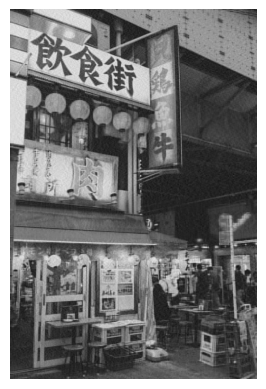

In [67]:
# Reconstruimos la imagen usando 100 componentes
k = 100
Ak100 = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])

# Guarda la imagen reconstruida
plt.imsave('Images/grayAk100.jpg', Ak100, cmap='gray')

# Muestra el resultado de la reconstrucción
plt.imshow(Ak100, cmap = 'gray')
plt.axis('off')
plt.show()

### 1.3.5. k = 200

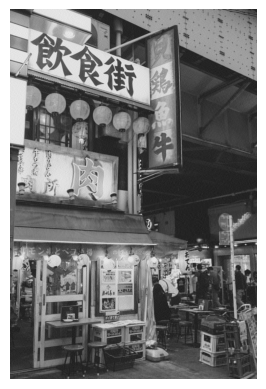

In [68]:
# Reconstruimos la imagen usando 200 componentes
k = 200
Ak200 = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])

# Guarda la imagen reconstruida
plt.imsave('Images/grayAk200.jpg', Ak200, cmap='gray')

# Muestra el resultado de la reconstrucción
plt.imshow(Ak200, cmap = 'gray')
plt.axis('off')
plt.show()

# 2. Análisis Cuantitativo

## 2.1. Tasa de Compresión

Tamaño original (en datos) =  4093 x 2729 = 11169797 

Usando  5  componentes:
Tamaño comprimido (en datos) =  5 x ( 4093 + 2729 + 1 ) = 34115
Tasa de compresión =  99.69457815571761 % 

Usando  20  componentes:
Tamaño comprimido (en datos) =  20 x ( 4093 + 2729 + 1 ) = 136460
Tasa de compresión =  98.7783126228704 % 

Usando  50  componentes:
Tamaño comprimido (en datos) =  50 x ( 4093 + 2729 + 1 ) = 341150
Tasa de compresión =  96.94578155717602 % 

Usando  100  componentes:
Tamaño comprimido (en datos) =  100 x ( 4093 + 2729 + 1 ) = 682300
Tasa de compresión =  93.89156311435202 % 

Usando  200  componentes:
Tamaño comprimido (en datos) =  200 x ( 4093 + 2729 + 1 ) = 1364600
Tasa de compresión =  87.78312622870406 % 



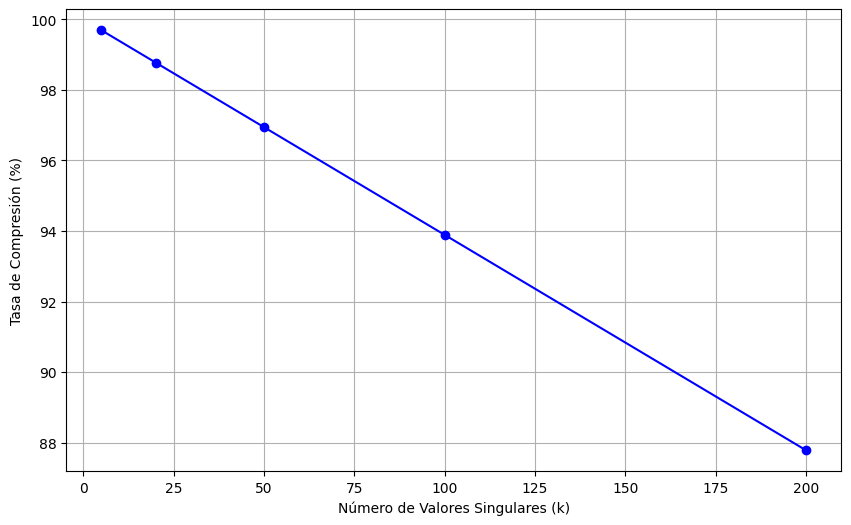

In [ ]:
m = A.shape[0]  # Número de filas
n = A.shape[1]  # Número de columnas
tamanoOriginal = m * n # Tamaño original (En datos, obviando cuántos bytes se necesitan para almacenar cada valor de píxel)

print("Tamaño original (en datos) = ", m, "x", n, "=", tamanoOriginal, "\n")

# Calcula la tasa de compresión usando k componentes
kArray = [5, 20, 50, 100, 200]
compresionArray = [] # Array para almacenar la tasa de compresión para cada valor de k
for k in kArray:
    tamanoComprimido = k * (m + n + 1) # Tamaño comprimido (En datos)
    print("Usando ", k, " componentes:")
    print("Tamaño comprimido (en datos) = ", k, "x (", m, "+", n, "+ 1 ) =", tamanoComprimido)
    tasaCompresion = (tamanoOriginal - tamanoComprimido) / tamanoOriginal * 100
    compresionArray.append(tasaCompresion)
    print("Tasa de compresión = ", tasaCompresion, "%", "\n")

# Grafica el porcentaje de compresión para cada valor de k
plt.figure(figsize=(10, 6))
plt.plot(kArray, compresionArray, 'bo-')
plt.xlabel('Número de Valores Singulares (k)')
plt.ylabel('Tasa de Compresión (%)')
plt.grid(True)
plt.show()

## 2.2. Análisis de Error

Error relativo para k = 5 componentes: 0.38487628443759
Error relativo para k = 20 componentes: 0.2457819162856576
Error relativo para k = 50 componentes: 0.16972132912192706
Error relativo para k = 100 componentes: 0.12187516737873796
Error relativo para k = 200 componentes: 0.08083690219131252


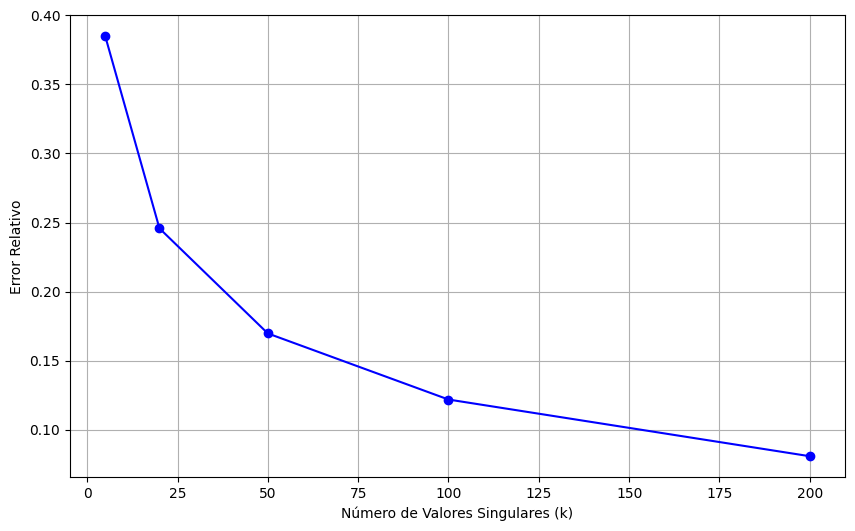

In [81]:
# Calcula el error relativo para cada valor de k
AkArray = [Ak5, Ak20, Ak50, Ak100, Ak200] # Array con las imágenes reconstruidas para cada valor de k
errRelativoArray = [] # Array para almacenar el error relativo para cada valor de k
for i, Ak in enumerate(AkArray):
    errRelativo = np.linalg.norm(A - Ak, 'fro') / np.linalg.norm(A, 'fro')
    errRelativoArray.append(errRelativo)
    print("Error relativo para k =", kArray[i], "componentes:", errRelativo)

# Grafica el error relativo para cada valor de k
plt.figure(figsize=(10, 6))
plt.plot(kArray, errRelativoArray, 'bo-')
plt.xlabel('Número de Valores Singulares (k)')
plt.ylabel('Error Relativo')
plt.grid(True)
plt.show()

## 2.3. Energía

Energía capturada para k = 5 componentes: 85.18702456775142 %
Energía capturada para k = 20 componentes: 93.959124962695 %
Energía capturada para k = 50 componentes: 97.11946704410865 %
Energía capturada para k = 100 componentes: 98.51464435764046 %
Energía capturada para k = 200 componentes: 99.34653952441121 %


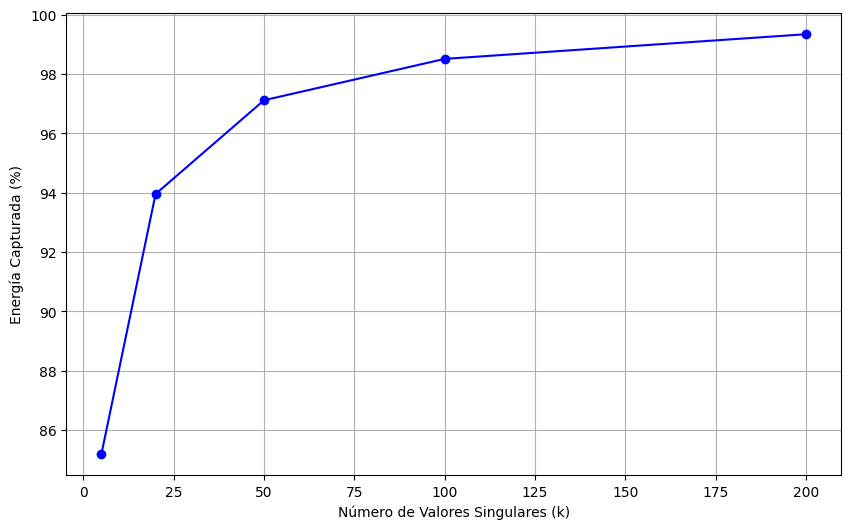

In [80]:
# Calcula la energía capturada para cada valor de k
energiaTotal = np.sum(S**2) # Energía total de la imagen original
energiaCapturadaArray = [] # Array para almacenar la energía capturada para cada valor de k
for k in kArray:
    energiaCapturada = np.sum(S[:k]**2) # Energía capturada usando los primeros k valores singulares
    energiaCapturadaArray.append(energiaCapturada / energiaTotal * 100) # Almacena el porcentaje de energía capturada
    print("Energía capturada para k =", k, "componentes:", energiaCapturada / energiaTotal * 100, "%")

# Grafica la energía capturada para cada valor de k
plt.figure(figsize=(10, 6))
plt.plot(kArray, energiaCapturadaArray, 'bo-')
plt.xlabel('Número de Valores Singulares (k)')
plt.ylabel('Energía Capturada (%)')
plt.grid(True)
plt.show()